In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tqdm import tqdm
import warnings
from torch.utils.data import random_split
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Augmentation & Splitting

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.95, 1.05)
    ),

    transforms.RandomPerspective(
        distortion_scale=0.1,
        p=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.1,
        scale=(0.02, 0.08),
        ratio=(0.3, 3.3)
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset WITHOUT transforms first
full_dataset = datasets.ImageFolder(root="/content/drive/MyDrive/Project 4/dataset")

# Split indices
dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

# Apply different transforms
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root="/content/drive/MyDrive/Project 4/dataset", transform=train_transform),
    train_subset.indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root="/content/drive/MyDrive/Project 4/dataset", transform=val_transform),
    val_subset.indices
)

test_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root="/content/drive/MyDrive/Project 4/dataset", transform=test_transform),
    test_subset.indices
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


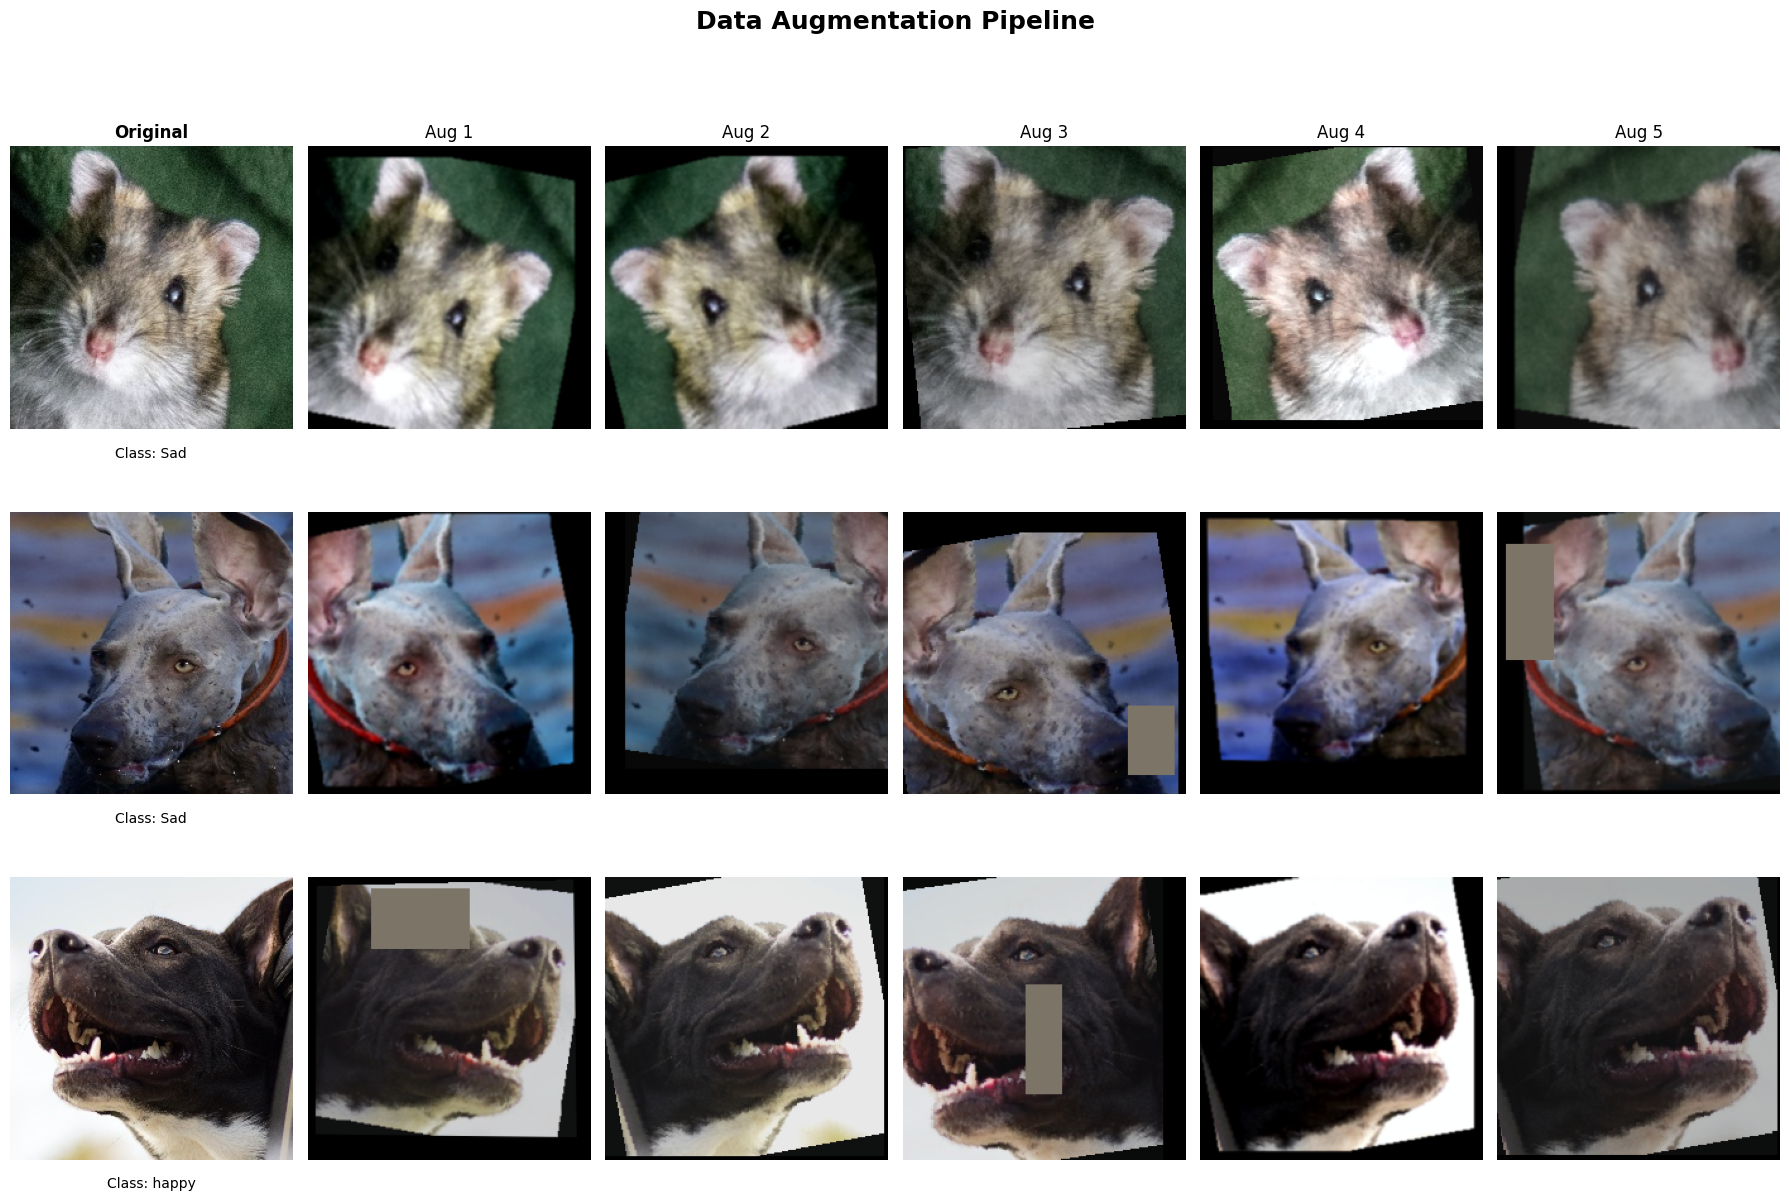

In [32]:
def visualize_augmentation_pipeline(dataset, num_samples=3):

    fig, axes = plt.subplots(num_samples, 6, figsize=(18, 4*num_samples))

    # Mean/std for denormalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for sample_idx in range(num_samples):

        # Actual index inside original ImageFolder
        real_idx = dataset.indices[sample_idx]

        # Access underlying ImageFolder
        base_dataset = dataset.dataset

        # Original image path
        original_path = base_dataset.samples[real_idx][0]

        from PIL import Image
        original_image = Image.open(original_path).convert('RGB')

        # Original image
        axes[sample_idx, 0].imshow(original_image)

        if sample_idx == 0:
            axes[sample_idx, 0].set_title(
                "Original",
                fontsize=12,
                fontweight='bold'
            )

        axes[sample_idx, 0].axis('off')

        class_idx = base_dataset.targets[real_idx]

        axes[sample_idx, 0].text(
            0.5,
            -0.1,
            f"Class: {base_dataset.classes[class_idx]}",
            transform=axes[sample_idx, 0].transAxes,
            ha='center',
            fontsize=10
        )

        # Show augmented versions
        for aug_idx in range(5):

            aug_image, _ = dataset[sample_idx]

            # Tensor -> numpy
            aug_np = aug_image.numpy().transpose(1, 2, 0)

            # Denormalize
            aug_np = std * aug_np + mean
            aug_np = np.clip(aug_np, 0, 1)

            axes[sample_idx, aug_idx + 1].imshow(aug_np)

            if sample_idx == 0:
                axes[sample_idx, aug_idx + 1].set_title(
                    f"Aug {aug_idx+1}",
                    fontsize=12
                )

            axes[sample_idx, aug_idx + 1].axis('off')

    plt.suptitle(
        "Data Augmentation Pipeline",
        fontsize=18,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()

visualize_augmentation_pipeline(train_dataset)

In [33]:
num_classes = len(train_dataset.dataset.classes)

print("Dataset sizes:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

print(f"Number of classes: {num_classes}")
print(f"Classes: {train_dataset.dataset.classes}")

Dataset sizes:
  Training samples: 700
  Validation samples: 150
  Test samples: 150
Number of classes: 4
Classes: ['Angry', 'Other', 'Sad', 'happy']


# Helper Functions

In [34]:
# The accuracy and mean Average: Precision, Recall, F1-score, and the confusion matrix helper functions
def calculate_metrics(y_true, y_pred, class_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']

    return precision, recall, f1_score

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

# Deep Learning Architecture: DenseNet-121 Detailed Breakdown

This notebook provides a structural breakdown of **Densely Connected Convolutional Networks (DenseNet-121)**, analyzing the conceptual hierarchy between layers and blocks, visualizing the pipeline, and defining the specific role of each implemented PyTorch class.

---

## 1. Dense Layer vs. Dense Block: The Core Difference

Think of it as a structural hierarchy: **a `DenseLayer` is a single individual worker, while a `DenseBlock` is a sequential team of those workers.**

*   **`DenseLayer` (The Individual Module):** This represents a single localized feature extraction step. It takes an input tensor, passes it through a channel bottleneck ($1 \times 1$ convolution) and a spatial filter ($3 \times 3$ convolution) to produce exactly $k$ (growth rate) new feature maps. Finally, it takes its original input and **concatenates** those $k$ new feature maps to it.
*   **`DenseBlock` (The Structural Grouping):** This is an operational container that stacks multiple `DenseLayer` modules back-to-back. If a `DenseBlock` is configured with `num_layers=6`, it sets up a chain reaction where Layer 1's concatenated output feeds straight into Layer 2, Layer 2's output into Layer 3, and so on.

---

## 2. The Full DenseNet-121 Pipeline

The visual map below traces how your four classes hook together sequentially to construct the entire network end-to-end. Notice the alternating pattern of expanding Dense Blocks and downsampling Transition Layers.

<br>

<img src="https://github.com/m-shalll/Computer-Vision-Projects/blob/Project4/Project%204/densenet121.png?raw=1" alt="Complete DenseNet-121 architecture diagram detailing the sequential pipeline: input image, Conv 7x7 step, MaxPool, followed by alternating Dense Blocks and Transition Layers, finishing with Global Average Pooling and a Fully Connected classification layer." width="900px" style="display: block; margin: 0 auto;"/>

<br>

---

## 3. Detailed Class-by-Class Functional Breakdown

Below is the operational mandate for each class within your PyTorch architecture as data propagates feedforward through the network.

### Class 1: `DenseLayer` (Feature Generator)
*   **Purpose:** It is the localized mathematical engine of the model. Its sole job is to generate exactly $k$ brand-new feature maps from whatever tensor volume it is handed.
*   **Execution Pipeline:**
    1. Applies **Pre-Activation** processing (`BatchNorm2d` $\rightarrow$ `ReLU`) to stabilize early signals.
    2. Uses a **$1 \times 1$ Bottleneck Convolution** to squash expanding input channels down to a fixed $4 \times k$ thickness, preventing subsequent layers from slowing down.
    3. Applies a secondary `BatchNorm2d` $\rightarrow$ `ReLU` sequence.
    4. Employs a **$3 \times 3$ Convolution** to extract spatial patterns, outputting exactly $k$ channels.
    5. **`torch.cat([...], dim=1)`**: Appends those $k$ new channels directly onto the original input channels.

### Class 2: `DenseBlock` (The Accumulator)
*   **Purpose:** It orchestrates a chain reaction of recursive feature reuse, packaging multiple `DenseLayer` modules into an interconnected web.
*   **Execution Pipeline:**
    * It tracks the network's channel growth profile. Because every layer appends $k$ channels, layer 0 accepts $C$ channels, layer 1 accepts $C + k$ channels, layer 2 accepts $C + 2k$ channels, and so on.
    * By the time data exits this block, the global channel depth has grown significantly by a factor of $\text{num\_layers} \times k$.

### Class 3: `TransitionLayer` (The Compressor & Resizer)
*   **Purpose:** It acts as a structural safety valve between massive Dense Blocks. Because Dense Blocks aggressively grow channel depth while locking spatial resolutions, the transition layer steps in to downsize the tensor matrix footprint.
*   **Execution Pipeline:**
    1. Passes the tensor through a **$1 \times 1$ Convolution** to compress the accumulated channel depth strictly in half (`num_channels // 2`).
    2. Utilizes a **$2 \times 2$ Average Pooling** layer with a stride of 2 to slice the height and width resolutions exactly in half, clearing a clean, downscaled tensor for the next block.

### Class 4: `DenseNet121` (The Executive Director)
*   **Purpose:** It defines the macro-architecture layout. It initializes the raw image processing stem, instantiates the definitive layer configurations `[6, 12, 24, 16]`, and manages global output pooling.
*   **Execution Pipeline:**
    1. **The Feature Stem (`self.features`):** Ingests raw 3-channel images. Uses an intensive $7 \times 7$ convolution and a $3 \times 3$ MaxPool to rapidly downscale spatial size while expanding depth to a baseline of 64 channels.
    2. **The Backbone Loop:** Cycles the tensor sequentially through alternating instances of `DenseBlock` and `TransitionLayer`.
    3. **The Prediction Head:** Applies a final global BatchNorm and ReLU, runs an `adaptive_avg_pool2d` to collapse spatial dimensions down to a clean $1 \times 1$ pixel average, flattens the matrix into a 1D vector, and passes it through a final linear layer (`self.classifier`) to yield class output probabilities.

## Code

In [35]:

# =========================
# Dense Layer
# =========================
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()

        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),

            # Bottleneck layer
            nn.Conv2d(
                in_channels,
                4 * growth_rate,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(4 * growth_rate),
            nn.ReLU(inplace=True),

            # 3x3 convolution
            nn.Conv2d(
                4 * growth_rate,
                growth_rate,
                kernel_size=3,
                padding=1,
                bias=False
            )
        )

    def forward(self, x):
        new_features = self.layer(x)

        # Concatenate input with new features
        return torch.cat([x, new_features], dim=1)


# =========================
# Dense Block
# =========================
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()

        layers = []

        for i in range(num_layers):
            layers.append(
                DenseLayer(
                    in_channels + i * growth_rate,
                    growth_rate
                )
            )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# =========================
# Transition Layer
# =========================
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()

        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.AvgPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.layer(x)


# =========================
# DenseNet121
# =========================
class DenseNet121(nn.Module):

    def __init__(self, num_classes=2, growth_rate=32):
        super(DenseNet121, self).__init__()

        # Initial convolution
        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )

        # DenseNet121 configuration
        block_layers = [6, 12, 24, 16]

        num_channels = 64

        # ===== Dense Block 1 =====
        self.denseblock1 = DenseBlock(
            block_layers[0],
            num_channels,
            growth_rate
        )

        num_channels += block_layers[0] * growth_rate

        self.transition1 = TransitionLayer(
            num_channels,
            num_channels // 2
        )

        num_channels = num_channels // 2

        # ===== Dense Block 2 =====
        self.denseblock2 = DenseBlock(
            block_layers[1],
            num_channels,
            growth_rate
        )

        num_channels += block_layers[1] * growth_rate

        self.transition2 = TransitionLayer(
            num_channels,
            num_channels // 2
        )

        num_channels = num_channels // 2

        # ===== Dense Block 3 =====
        self.denseblock3 = DenseBlock(
            block_layers[2],
            num_channels,
            growth_rate
        )

        num_channels += block_layers[2] * growth_rate

        self.transition3 = TransitionLayer(
            num_channels,
            num_channels // 2
        )

        num_channels = num_channels // 2

        # ===== Dense Block 4 =====
        self.denseblock4 = DenseBlock(
            block_layers[3],
            num_channels,
            growth_rate
        )

        num_channels += block_layers[3] * growth_rate

        # Final batch norm
        self.final_bn = nn.BatchNorm2d(num_channels)

        # Classification layer
        self.classifier = nn.Linear(
            num_channels,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        x = self.denseblock1(x)
        x = self.transition1(x)

        x = self.denseblock2(x)
        x = self.transition2(x)

        x = self.denseblock3(x)
        x = self.transition3(x)

        x = self.denseblock4(x)

        x = self.final_bn(x)

        x = F.relu(x, inplace=True)

        # Global Average Pooling
        x = F.adaptive_avg_pool2d(x, (1, 1))

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [36]:
# Training Function
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Acc": f"{100 * correct / total:.2f}%"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return (
        epoch_loss,
        epoch_acc,
        np.array(all_labels),
        np.array(all_preds)
    )

In [37]:
# Validation Function
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        progress_bar = tqdm(loader, desc="Validation", leave=False)

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress_bar.set_postfix({
                "Loss": f"{loss.item():.4f}",
                "Acc": f"{100 * correct / total:.2f}%"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return (
        epoch_loss,
        epoch_acc,
        np.array(all_labels),
        np.array(all_preds)
    )



In [38]:
# Evaluation Function
def evaluate_model(model, loader, criterion, class_names, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        progress_bar = tqdm(loader, desc="Evaluating", leave=False)

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / len(loader)
    test_acc = 100 * correct / total

    # Metrics
    precision, recall, f1_score = calculate_metrics(
        all_labels,
        all_preds,
        class_names
    )

    print("\n========== Test Results ==========")

    print(f"Loss      : {test_loss:.4f}")
    print(f"Accuracy  : {test_acc:.2f}%")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1_score:.4f}")

    print("\nClassification Report:\n")

    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    ))

    # Confusion Matrix
    plot_confusion_matrix(
        all_labels,
        all_preds,
        class_names
    )

    return {
        "loss": test_loss,
        "accuracy": test_acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }

In [39]:
import torch

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10,
    patience=3,
    save_path="best_model_DenseNet121.pth"
):

    # History dictionary
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):

        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print("-" * 50)

        # Training
        train_loss, train_acc, _, _ = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        # Validation
        val_loss, val_acc, _, _ = validate(
            model,
            val_loader,
            criterion,
            device
        )

        # Store history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Print results
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.2f}%")

        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.2f}%")

        # Early Stopping & Model Saving Logic
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0  # Reset counter because we found a new best accuracy

            torch.save(
                model.state_dict(),
                save_path
            )
            print(f"New best validation accuracy! Saved model weights to {save_path}")
        else:
            patience_counter += 1  # No improvement, increment counter
            print(f"No improvement in validation accuracy. Patience counter: {patience_counter}/{patience}")

        # Check if patience threshold has been breached
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered! Validation accuracy hasn't improved for {patience} epochs.")
            print("Stopping training early to prevent overfitting.")
            break

    print("\nTraining Complete!")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

    return history

In [40]:
def plot_training_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)

    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)

    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Model
model = DenseNet121(num_classes=num_classes).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4
)

# Train model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    patience=10,
    device=device,
    num_epochs=100
)


Epoch [1/100]
--------------------------------------------------


Train Loss : 1.4002
Train Acc  : 27.86%
Val Loss   : 1.3998
Val Acc    : 24.67%
New best validation accuracy! Saved model weights to best_model_DenseNet121.pth

Epoch [2/100]
--------------------------------------------------


Train Loss : 1.3620
Train Acc  : 32.57%
Val Loss   : 1.3947
Val Acc    : 25.33%
New best validation accuracy! Saved model weights to best_model_DenseNet121.pth

Epoch [3/100]
--------------------------------------------------


Train Loss : 1.3743
Train Acc  : 30.86%
Val Loss   : 1.4379
Val Acc    : 30.67%
New best validation accuracy! Saved model weights to best_model_DenseNet121.pth

Epoch [4/100]
--------------------------------------------------


Train Loss : 1.3446
Train Acc  : 34.14%
Val Loss   : 1.3637
Val Acc    : 28.67%
No improvement in validation accuracy. Patience counter: 1/10

Epoch [5/100]
--------------------------------------------------


...

Train Loss : 0.3436
Train Acc  : 89.57%
Val Loss   : 1.0116
Val Acc    : 76.00%
No improvement in validation accuracy. Patience counter: 1/10

Epoch [97/100]
--------------------------------------------------


Train Loss : 0.3770
Train Acc  : 86.14%
Val Loss   : 0.6302
Val Acc    : 80.00%
No improvement in validation accuracy. Patience counter: 2/10

Epoch [98/100]
--------------------------------------------------


Train Loss : 0.3749
Train Acc  : 87.29%
Val Loss   : 1.0670
Val Acc    : 72.00%
No improvement in validation accuracy. Patience counter: 3/10

Epoch [99/100]
--------------------------------------------------


Train Loss : 0.3710
Train Acc  : 87.29%
Val Loss   : 0.6448
Val Acc    : 78.67%
No improvement in validation accuracy. Patience counter: 4/10

Epoch [100/100]
--------------------------------------------------


Train Loss : 0.2555
Train Acc  : 90.71%
Val Loss   : 0.7545
Val Acc    : 76.67%
No improvement in validation accuracy. Patience counter: 5/10

Training Complete!
Best Validation Accuracy: 83.33%


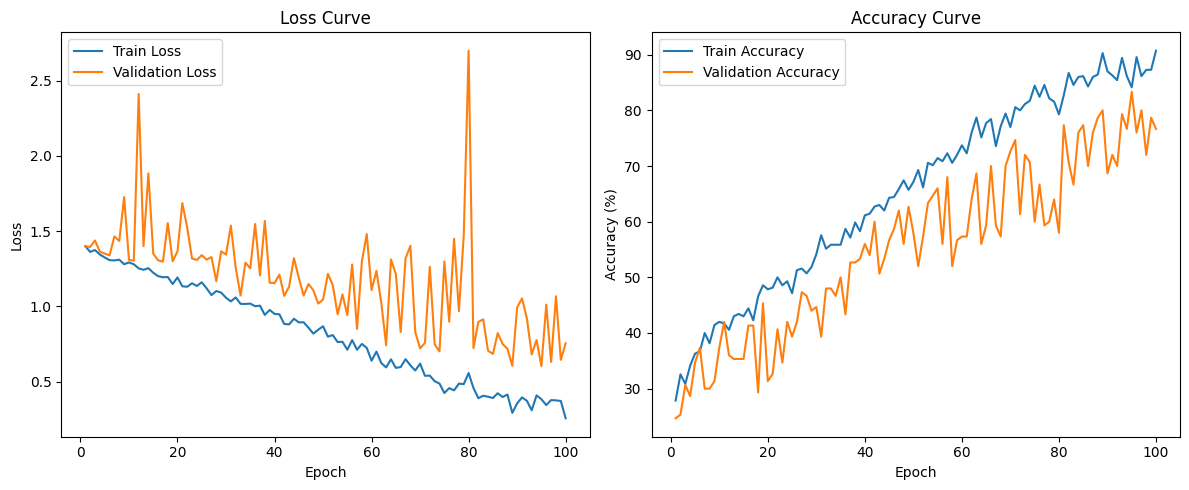

In [42]:
plot_training_history(history)


========== Test Results ==========
Loss      : 0.8127
Accuracy  : 76.00%
Precision : 0.7896
Recall    : 0.7600
F1-Score  : 0.7535

Classification Report:

              precision    recall  f1-score   support

       Angry       0.65      0.90      0.76        41
       Other       0.93      0.47      0.62        30
         Sad       0.80      0.80      0.80        44
       happy       0.82      0.80      0.81        35

    accuracy                           0.76       150
   macro avg       0.80      0.74      0.75       150
weighted avg       0.79      0.76      0.75       150



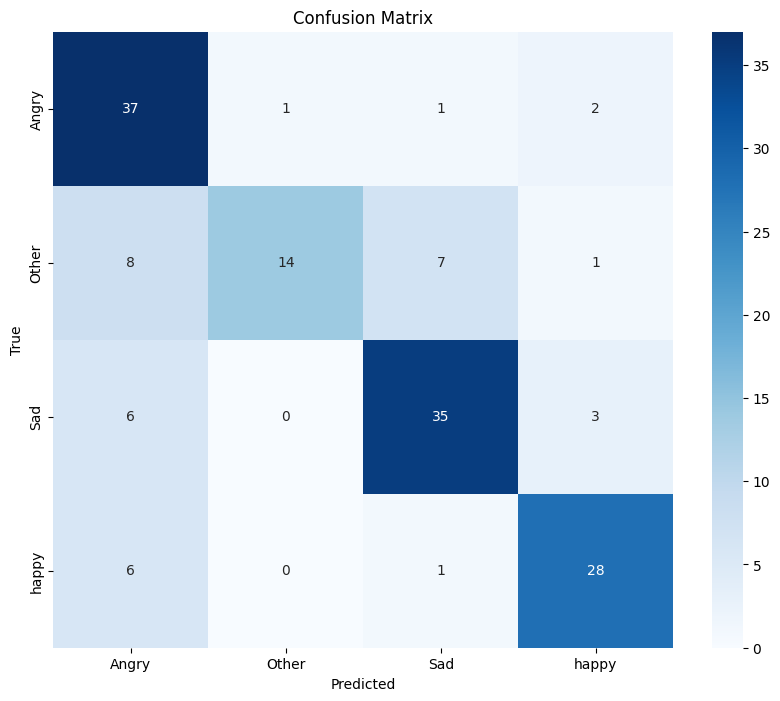

In [1]:
model.load_state_dict(
    torch.load("best_model_DenseNet121.pth", map_location=device)
)
dense_loss, dense_accuracy, dense_precision, dense_recall, dense_f1_score = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    class_names=train_dataset.dataset.classes,
    device=device
)